# Coding Regions
Look at the coding and complementary non-coding regions.

How does information differ between them?

## Data from Ensembl REST
Obtain sequence chunks of species *x* and corresponding binary labels for coding region positions.



In [1]:
import sys
import requests
import random
from collections import Counter
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

#species = 'homo_sapiens'
species = 'mus_musculus'
server = "https://rest.ensembl.org"

### Species info
Get info about the species, namely, the chromosome names.

In [2]:
ext = f"/info/assembly/{species}?"
 
r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
 
if not r.ok:
  r.raise_for_status()
  sys.exit()
 
res = r.json()
res

{'golden_path': 2728222451,
 'karyotype': ['1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  '10',
  '11',
  '12',
  '13',
  '14',
  '15',
  '16',
  '17',
  '18',
  '19',
  'X',
  'Y',
  'MT'],
 'top_level_region': [{'name': 'MU069434.1',
   'length': 8412,
   'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'length': 31129, 'name': 'MU069435.1'},
  {'coord_system': 'scaffold', 'length': 40056, 'name': 'GL456239.1'},
  {'coord_system': 'scaffold', 'name': 'GL456359.1', 'length': 22974},
  {'coord_system': 'scaffold', 'name': 'GL456368.1', 'length': 20208},
  {'coord_system': 'scaffold', 'length': 35240, 'name': 'GL456385.1'},
  {'coord_system': 'scaffold', 'length': 1976, 'name': 'JH584295.1'},
  {'name': 'GL456396.1', 'length': 21240, 'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'name': 'GL456370.1', 'length': 26764},
  {'name': 'GL456360.1', 'length': 31704, 'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'name': 'GL456382.1', 'lengt

In [3]:
[ print(x) for x in res.keys() ]
#res['karyotype']
chromosomes = {}
for r in res['top_level_region']:
    if r['coord_system'] == 'chromosome':
        chromosomes[r['name']] = r['length']


golden_path
karyotype
top_level_region
genebuild_last_geneset_update
coord_system_versions
assembly_accession
genebuild_initial_release_date
assembly_name
genebuild_start_date
assembly_date
genebuild_method
default_coord_system_version


## Random Sample Generator
A generator of random samples, chosen from some region *r* of size |*r*| in some chromosome. 

In [26]:
random.seed(777)

def get_random_regions(seq_regions: list, sample_len: int, lengths: dict) -> list:
    res = []
    for s in seq_regions:
        
        # get length of this seq region from lengths dict
        s_len = lengths[s]
        # get random region end point
        end = random.randint(sample_len, s_len)
        
        # calculate start point,
        #  use 1-based indexing for Ensembl region query
        start = 1 + end - sample_len
        
        strand = random.choice(['1','-1'])
        res.append({
            'seq_region': s,
            'start': start,
            'end': end,
            'strand': strand,
            'len': end - start + 1
        })

    return res

n = 1000000 # n samples
sample_len = 99 # 99 nc sample size
x = random.choices(*zip(*chromosomes.items()), k=n)

random_regions = get_random_regions(x, sample_len, chromosomes)


In [27]:
lset = set()
for r in random_regions:
    lset.add(r['len'])

print(f"unique lengths {'; '.join(map(str, lset))}")

unique lengths 99


#### Check the distribution of samples over chromosomes
The counts should be proportional to the chromosome lenghts, os when normalised by the lengths they should be about the same.

In [6]:

# "Eye-ball the distrubution"
c = Counter(x)
df = pd.DataFrame([*chromosomes.items()], columns=['name', 'length'])
df['count'] = df['name'].apply(c.get, c.keys())
df['norm'] = df['count'] * 1000 / df['length']
#df.sort_values('name')
df

,name,length,count,norm
0,MT,16299,5,0.306767
1,Y,91455967,33430,0.365531
2,2,181755017,66275,0.364639
3,4,156860686,57706,0.367881
4,11,121973369,44990,0.368851
5,12,120092757,43627,0.363278
6,17,95294699,34874,0.365959
7,3,159745316,59219,0.370709
8,9,124359700,45587,0.366574
9,16,98008968,36095,0.368283


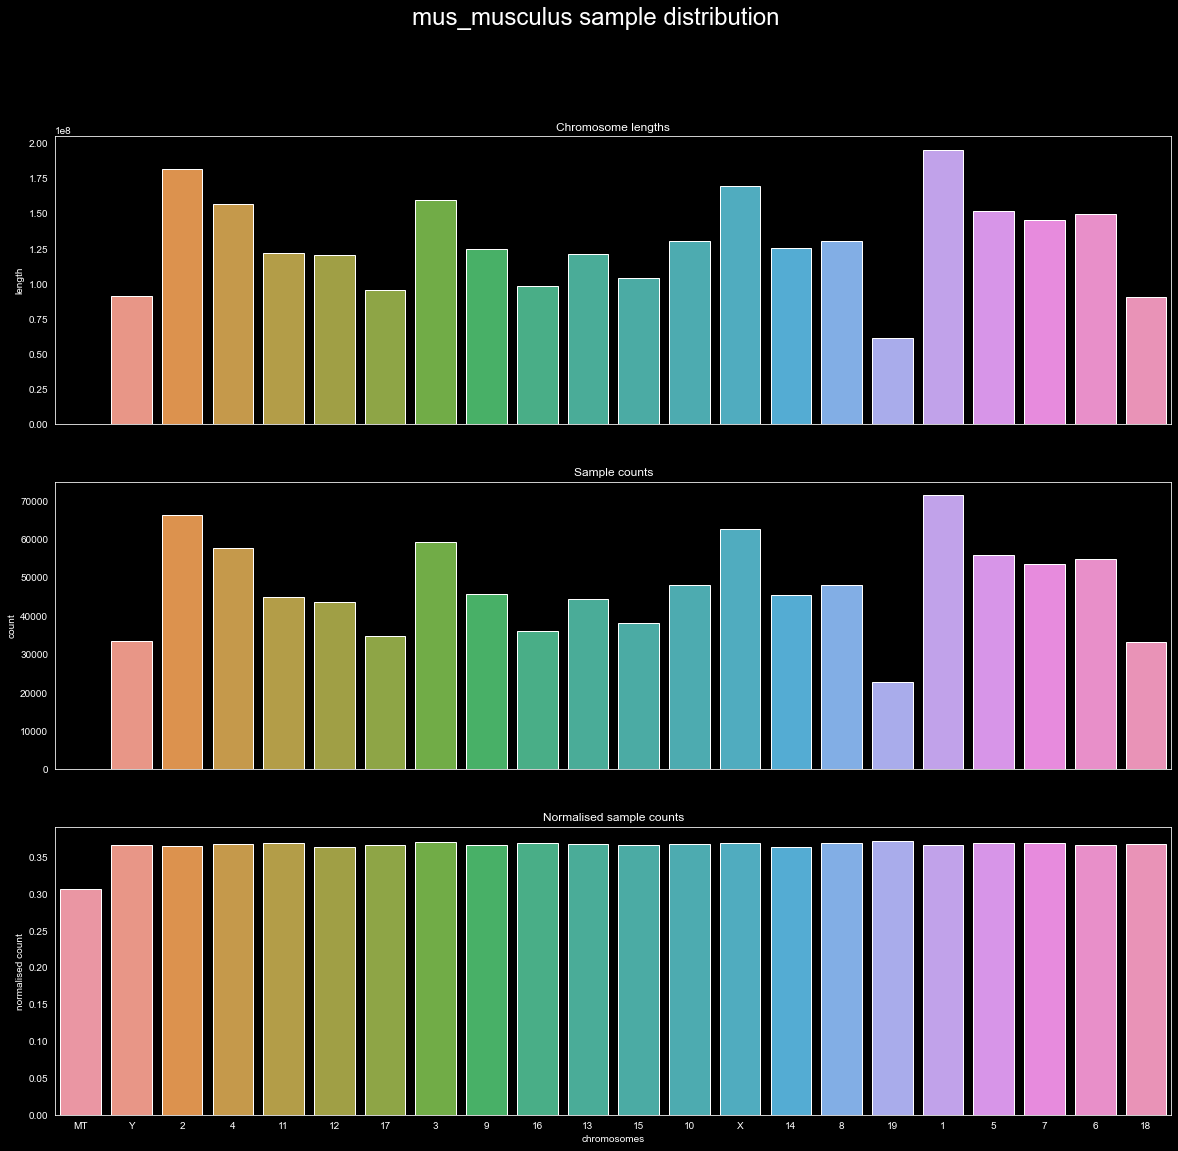

In [7]:

#sns.set_theme(style="darkgrid")
sns.set_style("darkgrid", {'axes.grid' : False})
plt.style.use("dark_background")

fig, ax = plt.subplots(nrows=3, figsize=(20,18), sharex=True)
sns.barplot(ax=ax[0], x='name', y='length', data=df)
ax[0].set_title("Chromosome lengths")
ax[0].set_xlabel("")

sns.barplot(ax=ax[1], x='name', y='count', data=df)
ax[1].set_title("Sample counts")
ax[1].set_xlabel("")

sns.barplot(ax=ax[2], x='name', y='norm', data=df)
ax[2].set_title("Normalised sample counts")
ax[2].set_xlabel("chromosomes")
ax[2].set_ylabel("normalised count")

fig.suptitle(f"{species} sample distribution", size=24)

#[x.grid(b=None, which='major', axis='both') for x in ax]
    
plt.show()



Yay, looks like that worked.

## Sample Region Data
Using the randomly generated region strings, generate query results for each region.

For each region:
 - Sequence
 - all cannonical transcripts
   - **include those partially inside region**
 - Generate labels for positions of
   - exons
   - CDS
   - UTRs ? but these are implied by the exon - CDS difference so duplicate data?
        
        

In [10]:
region_str = lambda r: r['seq_region'] + \
            f":{r['start']}-{r['end']}:" + \
            r['strand']

def get_region_seq(region):
        
    ext = f"/sequence/region/{species}/{region_str(region)}"
    r = requests.get(server+ext, headers={ "Content-Type" : "text/x-fasta"})
 
    if not r.ok:
      r.raise_for_status()
 
    return r.text

test_seq = get_region_seq(random_regions[0])
print(test_seq)

>chromosome:GRCm39:12:14891088:14891186:-1
AAACACCAGGTGTAGATGTGGACTTCCAAATTATAACTTCACTACAGCCATCTCTCATAA
GCTTCACTTTTTTTGTACACTATGGATTTATGTGTTATA



In [48]:
import numpy as np
def get_region_labels(region, feature_types=['exon', 'cds'], transcript_strategy='cannonical'):
    """
    This should return a numpy 2darray of zeros and ones
    with shape (region_length, len(feature_types)). That is
    a column of exon labels, and a column of CDS labels,
    by default.
    
    Transcript splice variants are handled by transcript_strategy.
    'cannonical' selects only cannonical transcript sub-features.
    'merge' combines overlapping features of the same type,
    if in the same gene, e.g. all exons from all transcripts
    of a particular gene.
    """
    
    fstr = lambda flist: ';'.join([f"feature={f}" for f in flist])
    
    print(feature_types)
    
    # get transcripts + exons, CDS etc in region
    ext = f"/overlap/region/{species}/{region_str(region)}?feature=transcript;{fstr(feature_types)};biotype=protein_coding"
    print(ext)
    r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
    
    if not r.ok:
        r.raise_for_status()

    json = r.json()
    if not json:
        return np.zeros((region['len'], len(feature_types)), dtype=np.int8)
    
    # filter for those from cannonical transcripts only
    if transcript_strategy == 'cannonical':
        pass
    
    # Make labels 2d array

    return json



count = 7
test_labels = get_region_labels(random_regions[count])
while np.all(test_labels==0):
    count += 1
    test_labels = get_region_labels(random_regions[count])
print(count)

['exon', 'cds']
/overlap/region/mus_musculus/6:88285920-88286018:-1?feature=transcript;feature=exon;feature=cds;biotype=protein_coding
7


In [49]:
test_labels

[{'transcript_support_level': '1 (assigned to previous version 3)',
  'feature_type': 'transcript',
  'source': 'ensembl_havana',
  'description': None,
  'biotype': 'protein_coding',
  'strand': 1,
  'logic_name': 'ensembl_havana_transcript_mus_musculus',
  'start': 88234316,
  'ccdsid': 'CCDS20335.1',
  'external_name': 'Eefsec-201',
  'end': 88423521,
  'assembly_name': 'GRCm39',
  'seq_region_name': '6',
  'id': 'ENSMUST00000165242',
  'tag': 'basic',
  'version': 4,
  'transcript_id': 'ENSMUST00000165242',
  'Parent': 'ENSMUSG00000033216'},
 {'external_name': 'Eefsec-206',
  'tag': 'basic',
  'id': 'ENSMUST00000205179',
  'seq_region_name': '6',
  'end': 88423509,
  'assembly_name': 'GRCm39',
  'transcript_id': 'ENSMUST00000205179',
  'version': 3,
  'Parent': 'ENSMUSG00000033216',
  'transcript_support_level': '1 (assigned to previous version 2)',
  'feature_type': 'transcript',
  'biotype': 'protein_coding',
  'description': None,
  'source': 'havana',
  'strand': 1,
  'start': 